## Lab 5.3: Explaining CNN Outputs

In this lab you will implement the Grad-CAM method for visualizing the feature maps inside a CNN.

In [1]:
!wget -q -nc -O brambling.jpg "https://www.dropbox.com/scl/fi/2s7ytfxqh2q1psua7pqi6/brambling.jpg?rlkey=rua4fnoi3kwd57dufxn1vre73&dl=1"
!wget -q -nc -O tiger_shark.jpg "https://www.dropbox.com/scl/fi/63j3yjdy411xxyc7gh8oj/tiger_shark.jpg?rlkey=8s9r0076dcai2yrkn657c364d&dl=1"
!wget -q -nc -O garbage_truck.jpg "https://www.dropbox.com/scl/fi/w3fnqf0dsffnw65fla329/garbage_truck.jpg?rlkey=pt3rfefc0kwxfz8t9lcpmxfjq&dl=1"
!wget -q -nc -O chai_tea_muffin.jpg "https://www.dropbox.com/scl/fi/cai031qoypqnfd77tac8c/chai_tea_muffin.jpg?rlkey=cjmu9tv5kaphmaiq06vlg432t&dl=1"

In [2]:
from PIL import Image
from matplotlib import pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
import torchvision
from torchvision.transforms.functional import resize, to_tensor
from torchvision.transforms.v2 import InterpolationMode

I collected some CC-licensed images for you along with appropriate ImageNet labels. 

You can find the complete list of ImageNet class names [here](https://deeplearning.cms.waikato.ac.nz/user-guide/class-maps/IMAGENET/).

In [3]:
filename = 'brambling.jpg'
label = 10 # brambling    

# filename = 'tiger_shark.jpg'
# label = 3 # tiger shark

# filename = 'garbage_truck.jpg'
# label = 569 # garbage truck
# label = 770 # running shoes

# filename = 'chai_tea_muffin.jpg'
# label = 504 # coffee mug
# label = 923 # plate

Here we will use PIL to open the image and show it.

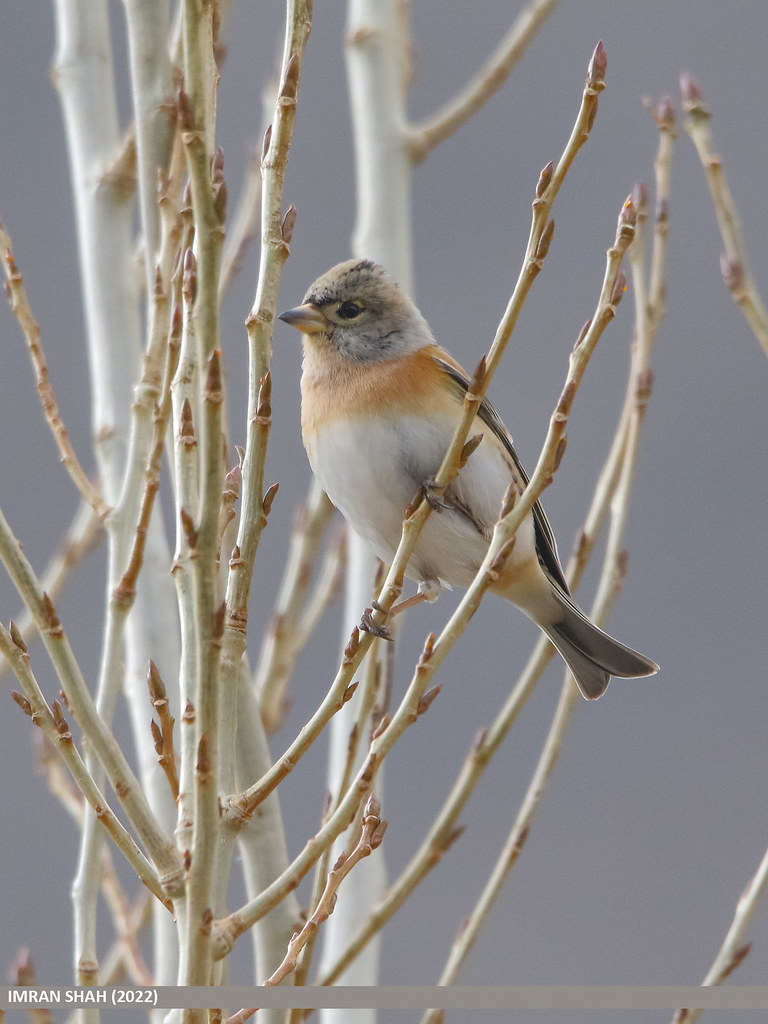

In [4]:
image = Image.open(filename)
image


Now we will load the VGG16 model with ImageNet-1K pre-trained weights.

In [5]:
import torch
from torchvision.models import VGG16_Weights, vgg16

In [6]:
weights = VGG16_Weights.IMAGENET1K_V1
model = vgg16(weights=weights)

This line puts the model into "evaluation" mode, so that it doesn't compute the gradients w.r.t. the model weights.  It makes inference faster and less memory-intensive.

In [7]:
model.eval()

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

We also grab the appropriate image transformations according to the chosen weights.  The model expects the input image to be resized to (224,224) and normalized according to the ImageNet color mean and std. dev.

In [8]:
transforms = weights.transforms()

In [9]:
def get_logits(model,image,transforms):
    """ Run VGG16 model on an image and return class logits.

        Arguments:
            model: VGG16 model
            image: PIL image
            transforms: torchvision transforms

        Returns:
            Class logits
    """
    # run transforms on image
    x = transforms(image) # [C,H,W]

    # add batch dimension
    x = x.unsqueeze(0)

    # feed forward through feature blocks
    for l in model.features:
        x = l(x)

    # flatten to vector
    x = x.flatten(start_dim=1)

    # feed forward through classifier
    for l in model.classifier:
        x = l(x)

    # remove the batch dimension
    logits = torch.squeeze(x,0)

    return logits

We can test the model to see if it is assigning the highest logit to the correct class.

In [10]:
logits = get_logits(model,image,transforms)
logits.argsort(descending=True)[:5], label

(tensor([10, 13, 11, 19, 12]), 10)

We see that indeed class 10 is the highest logit.

### Exercises

1. Complete the function `get_logits_and_feature_maps()` which runs the model as above, but also returns a list of feature maps from the output of the convolutional layers.

Notes:
- You should save the outputs of the convolutional layers to a list of feature maps.
- You can determine if a layer is a convolutional layer by checking if the `type` is `Conv2d`.
- Make sure to call `.retain_grad()` on the feature map before saving it.  Otherwise, Torch will automatically discard the gradients, which we will need later.
- Run the image through the function and print out the shape of each feature map.  Your output should look like this:

```
feature map 0: torch.Size([1, 64, 224, 224])
feature map 1: torch.Size([1, 64, 224, 224])
feature map 2: torch.Size([1, 128, 112, 112])
feature map 3: torch.Size([1, 128, 112, 112])
feature map 4: torch.Size([1, 256, 56, 56])
feature map 5: torch.Size([1, 256, 56, 56])
feature map 6: torch.Size([1, 256, 56, 56])
feature map 7: torch.Size([1, 512, 28, 28])
feature map 8: torch.Size([1, 512, 28, 28])
feature map 9: torch.Size([1, 512, 28, 28])
feature map 10: torch.Size([1, 512, 14, 14])
feature map 11: torch.Size([1, 512, 14, 14])
feature map 12: torch.Size([1, 512, 14, 14])
```

In [ ]:
def get_logits_and_feature_maps(model,image,transforms):
    """ Run VGG16 model on an image and return class logits and feature maps.

        Arguments:
            model: VGG16 model
            image: PIL image
            transforms: torchvision transforms

        Returns:
            Output logits, list of feature maps
    """
    # YOUR CODE HERE
    # (COPY FROM ABOVE AND MODIFY)

2. Show the first five channels of the last feature map using `plt.imshow()`.

In [ ]:
# YOUR CODE HERE

3. Populate the feature map gradients by calling `.backward()` on the logit corresponding to the correct label.

Show the gradient of the first five channels in the last feature map.

In [ ]:
# YOUR CODE HERE

4. Now implement the Grad-CAM technique by completing this function.

Grad-CAM takes a chosen feature map and creates a visualization in the following manner:

1. Calculate the per-channel mean of the gradient -- these are the channel weights.
2. Multiply each channel of the feature map by its weight.
3. Compute a per-pixel sum of the weighted feature maps.
4. Apply ReLU to suppress negative outputs.

Show the Grad-CAM result for the last feature map.

In [ ]:
def gradcam(feature_map):
    """ 
    Calculates Grad-CAM for a feature map.

    Arguments:
        feature_map: [B,C,H,W] feature map; must have gradient calculated
    Returns:
        Grad-CAM visualization [B,H,W]
    """
    # YOUR CODE HERE


5. This function will use the Grad-CAM result as a mask, to highlight the corresponding regions of the image.

Apply the function and show the result.

In [ ]:
def get_cam_weighted_image(image,cam):
    """
    Calculate Grad-CAM weighted image.

    Arguments:
        image: PIL image
        cam: Grad-CAM result [H,W]
    
    Returns:
        Grad-CAM weighted image [C,H,W]
    """
    image = to_tensor(image)
    cam = resize(cam[None,:], image.shape[1:3], interpolation=InterpolationMode.BICUBIC)
    cam = cam/cam.max()
    res = image*cam
    return res.numpy().transpose((1,2,0))